<a href="https://colab.research.google.com/github/kukle2412/kukle/blob/main/mission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv

In [ ]:
import pandas as pd
import numpy as np

# CSV 파일 읽기
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/breast_cancer.csv')

# 필요없는 인덱스 컬럼 제거
df = df.drop('Unnamed: 0', axis=1)

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
y = df['label']
X = df.drop('label', axis=1)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
clf_lr = LogisticRegression(max_iter=5000)

clf_lr.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))

Logistic Regression
Accuracy: 0.951048951048951
[[52  1]
 [ 6 84]]


In [ ]:
clf_svm = SVC()

clf_svm.fit(X_train, y_train)

pred_svm = clf_svm.predict(X_test)

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))


SVM
Accuracy: 0.9370629370629371
[[45  8]
 [ 1 89]]


In [ ]:
clf_dt = DecisionTreeClassifier()

clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print(confusion_matrix(y_test, pred_dt))


Decision Tree
Accuracy: 0.8811188811188811
[[50  3]
 [14 76]]


In [ ]:
y = df['mean area']
X = df.drop(['mean area','label'], axis=1)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression MSE:", mean_squared_error(y_test, pred_lr))

Linear Regression MSE: 315.3585776308688


In [ ]:
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, pred_dt))

Decision Tree MSE: 307.62286713286716


In [ ]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest MSE:", mean_squared_error(y_test, pred_rf))

Random Forest MSE: 412.2388371188812


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test))

평균제곱근오차 315.3585776308688
평균제곱근오차 315.3585776308688
평균제곱근오차 315.3585776308688


<>:16: SyntaxWarning: invalid decimal literal
<>:16: SyntaxWarning: invalid decimal literal
/tmp/ipykernel_2275/3032514812.py:16: SyntaxWarning: invalid decimal literal
  sum_square_error = sum((a - p) ** 2for a, p in zip(actual, predicted))


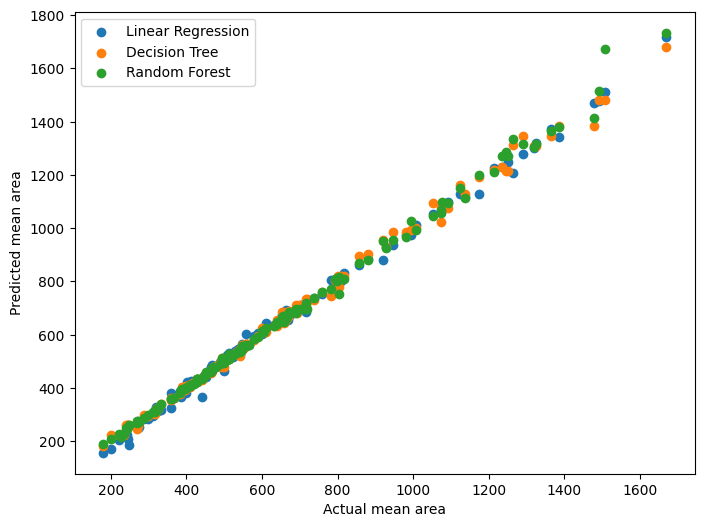

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_lr, label="Linear Regression")
plt.scatter(y_test, pred_dt, label="Decision Tree")
plt.scatter(y_test, pred_rf, label="Random Forest")

plt.xlabel("Actual mean area")
plt.ylabel("Predicted mean area")

plt.legend()
plt.show()